# Datos Statsbomb

### Radar Chart

### Import libraries

In [ ]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from mplsoccer import FontManager
from PIL import Image
from io import BytesIO

### Importar datos

In [ ]:
df_origin = pd.read_csv('./Data/Statsbomb_Events_DB_Euro24.csv', low_memory=False)

In [ ]:
df_player_stats = df_origin.copy()

### Minutos jugados

In [ ]:
# 1. Calcular los minutos jugados POR PARTIDO para cada jugador
# Agrupamos por jugador Y por partido, y calculamos la diferencia de minutos
minutos_por_partido = (
    df_player_stats.groupby(['player_id','player_name', 'match_id', 'team_name'])['minute'].agg(lambda x: x.max() - x.min()).reset_index()
)

In [ ]:
# 2. Sumar los minutos de todos los partidos para cada jugador
df_minutos = minutos_por_partido.groupby(['player_id', 'player_name', 'team_name'])['minute'].sum()

In [ ]:
df_minutos.head()

player_id  player_name           team_name  
2954.0     Youri Tielemans       Belgium        154
2972.0     Marcus Thuram         France         258
2988.0     Memphis Depay         Netherlands    463
3009.0     Kylian Mbappé Lottin  France         469
3026.0     Adrien Rabiot         France         373
Name: minute, dtype: int64

### 1. Tiros y xG

In [ ]:
tiros = df_player_stats[df_player_stats['type_name'] == 'Shot'].copy()
df_tiros = tiros.groupby(['player_id', 'player_name', 'team_name']).agg(
    Goles=('outcome_name', lambda x: (x == 'Goal').sum()),
    Disparos=('id', 'count'),
    xG=('shot_statsbomb_xg', 'sum')
).reset_index()

In [ ]:
df_tiros.head()

,player_id,player_name,team_name,Goles,Disparos,xG
0,2954.0,Youri Tielemans,Belgium,1,4,0.153319
1,2972.0,Marcus Thuram,France,0,12,1.178654
2,2988.0,Memphis Depay,Netherlands,1,18,1.951101
3,3009.0,Kylian Mbappé Lottin,France,1,24,2.506847
4,3026.0,Adrien Rabiot,France,0,3,0.262040


### 2. Pases y Creación (xA)

In [ ]:
pases = df_player_stats[df_player_stats['type_name'] == 'Pass'].copy()
# Pases completados (en StatsBomb open-data, pass_outcome NaN significa éxito)
pases['completado'] = pases['outcome_name'].isna().astype(int)
# Pases clave (pases que desembocan en tiro)
pases['es_pase_clave'] = pases['pass_assisted_shot_id'].notna().astype(int)
# xA (si está disponible en los metadatos del pase)
if 'pass_shot_assist_xg' in pases.columns:
    pases['xA'] = pases['pass_shot_assist_xg'].fillna(0)
else:
    pases['xA'] = 0

df_pases = pases.groupby(['player_id', 'player_name', 'team_name']).agg(
    Pases_Intentados=('id', 'count'),
    Pases_Completados=('completado', 'sum'),
    Pases_Clave=('es_pase_clave', 'sum'),
    xA=('xA', 'sum')
).reset_index()

In [ ]:
df_pases.head()

,player_id,player_name,team_name,Pases_Intentados,Pases_Completados,Pases_Clave,xA
0,2954.0,Youri Tielemans,Belgium,117,101,1,0
1,2972.0,Marcus Thuram,France,56,46,1,0
2,2988.0,Memphis Depay,Netherlands,166,112,11,0
3,3009.0,Kylian Mbappé Lottin,France,184,160,3,0
4,3026.0,Adrien Rabiot,France,235,214,10,0


### 3. Conducciones Progresivas

In [ ]:
conducciones = df_player_stats[df_player_stats['type_name'] == 'Carry'].copy()
df_conducciones = conducciones.groupby(['player_id', 'player_name', 'team_name']).agg(
    Conducciones=('id', 'count')
).reset_index()

In [ ]:
df_conducciones.head()

,player_id,player_name,team_name,Conducciones
0,2954.0,Youri Tielemans,Belgium,91
1,2972.0,Marcus Thuram,France,58
2,2988.0,Memphis Depay,Netherlands,147
3,3009.0,Kylian Mbappé Lottin,France,208
4,3026.0,Adrien Rabiot,France,204


### 4. Acciones Defensivas (Presiones)

In [ ]:
presiones = df_player_stats[df_player_stats['type_name'] == 'Pressure'].copy()
df_presiones = presiones.groupby(['player_id', 'player_name', 'team_name']).agg(
    Presiones=('id', 'count')
).reset_index()

In [ ]:
df_presiones.head()

,player_id,player_name,team_name,Presiones
0,2954.0,Youri Tielemans,Belgium,17
1,2972.0,Marcus Thuram,France,42
2,2988.0,Memphis Depay,Netherlands,75
3,3009.0,Kylian Mbappé Lottin,France,40
4,3026.0,Adrien Rabiot,France,48


In [ ]:
# Unir todo en una sola tabla matriz
df_stats = df_tiros.merge(df_pases, on=['player_id', 'player_name', 'team_name'], how='outer')
df_stats = df_stats.merge(df_conducciones, on=['player_id', 'player_name', 'team_name'], how='outer')
df_stats = df_stats.merge(df_presiones, on=['player_id', 'player_name', 'team_name'], how='outer')
df_stats = df_stats.merge(df_minutos, on=['player_id', 'player_name', 'team_name'], how='inner') # Solo jugadores con minutos

df_stats = df_stats.fillna(0)

In [ ]:
df_stats.head()

,player_id,player_name,team_name,Goles,Disparos,xG,Pases_Intentados,Pases_Completados,Pases_Clave,xA,Conducciones,Presiones,minute
0,2954.0,Youri Tielemans,Belgium,1.0,4.0,0.153319,117.0,101.0,1.0,0.0,91.0,17.0,154
1,2972.0,Marcus Thuram,France,0.0,12.0,1.178654,56.0,46.0,1.0,0.0,58.0,42.0,258
2,2988.0,Memphis Depay,Netherlands,1.0,18.0,1.951101,166.0,112.0,11.0,0.0,147.0,75.0,463
3,3009.0,Kylian Mbappé Lottin,France,1.0,24.0,2.506847,184.0,160.0,3.0,0.0,208.0,40.0,469
4,3026.0,Adrien Rabiot,France,0.0,3.0,0.262040,235.0,214.0,10.0,0.0,204.0,48.0,373


In [ ]:
df_stats.columns.to_list()

['player_id',
 'player_name',
 'team_name',
 'Goles',
 'Disparos',
 'xG',
 'Pases_Intentados',
 'Pases_Completados',
 'Pases_Clave',
 'xA',
 'Conducciones',
 'Presiones',
 'minute']

#### Team colors and logo

In [ ]:
df_team_mapping = pd.read_excel('../Data/Providers_Team_Mapping.xlsx')
df_stats = df_stats.merge(df_team_mapping[['Statsbomb', 'Team_Color', 'Team_Logo']],how='left',left_on='team_name',right_on='Statsbomb')
df_stats.drop(columns='Statsbomb', inplace=True)

### Radar Chart

In [ ]:
df_stats.head()

,player_id,player_name,team_name,Goles,Disparos,xG,Pases_Intentados,Pases_Completados,Pases_Clave,xA,Conducciones,Presiones,minute,Team_Color,Team_Logo
0,2954.0,Youri Tielemans,Belgium,1.0,4.0,0.153319,117.0,101.0,1.0,0.0,91.0,17.0,154,#8A0B11,https://media.api-sports.io/football/teams/1.png
1,2972.0,Marcus Thuram,France,0.0,12.0,1.178654,56.0,46.0,1.0,0.0,58.0,42.0,258,#002395,https://media.api-sports.io/football/teams/2.png
2,2988.0,Memphis Depay,Netherlands,1.0,18.0,1.951101,166.0,112.0,11.0,0.0,147.0,75.0,463,#FF6600,https://media.api-sports.io/football/teams/111...
3,3009.0,Kylian Mbappé Lottin,France,1.0,24.0,2.506847,184.0,160.0,3.0,0.0,208.0,40.0,469,#002395,https://media.api-sports.io/football/teams/2.png
4,3026.0,Adrien Rabiot,France,0.0,3.0,0.262040,235.0,214.0,10.0,0.0,204.0,48.0,373,#002395,https://media.api-sports.io/football/teams/2.png


In [ ]:
player1 = 'Kylian Mbappé Lottin'
player2 = 'Memphis Depay'

# parameter names of the statistics we want to sho
params = ['Goles','Disparos','xG','Pases_Intentados','Pases_Completados','Pases_Clave','xA','Conducciones','Presiones']
#params90 = ['Goles_p90','Disparos_p90','xG_p90','Pases_Intentados_p90','Pases_Clave_p90', 'xA_p90', 'Conducciones_p90', 'Presiones_p90']

In [ ]:
# Rankear todas las columnas en 'params' (percentil, mejor valor = rank más alto)
df_stats[params] = df_stats[params].rank(pct=True, ascending=True) * 100

In [ ]:
player1_values = df_stats.loc[df_stats['player_name'] == player1, params].values.flatten().tolist()
player2_values = df_stats.loc[df_stats['player_name'] == player2, params].values.flatten().tolist()

Team1 = df_stats.loc[df_stats['player_name'] == player1, 'team_name'].values[0]
Team2 = df_stats.loc[df_stats['player_name'] == player2, 'team_name'].values[0]

#### Customization

In [ ]:
font_title = FontManager('https://github.com/google/fonts/blob/main/ofl/bebasneue/BebasNeue-Regular.ttf?raw=true')

In [ ]:
def add_image_from_url(url, x_pos, y_pos, size, relative_to):
    """
    Añade una imagen a un gráfico desde una URL.

    Parámetros:
    - url: Link de la imagen.
    - x_pos, y_pos: Posición en el gráfico.
    - size: Tamaño (zoom) de la imagen (ej: 0.1).
    - relative_to:
        * 'data': Usa los números de los ejes (ej: Goles).
        * 'axes': Usa el área del gráfico (0 a 1).
        * 'figure': Usa toda la imagen final (0 a 1).
    """
    # Descarga y procesa la imagen
    response = requests.get(url, timeout=5)
    img = Image.open(BytesIO(response.content)).convert('RGBA')

    # Define el sistema de coordenadas
    coord_style = relative_to if relative_to == 'data' else f'{relative_to} fraction'

    # Crea y añade la imagen al gráfico
    imagebox = OffsetImage(img, zoom=size)
    ax.add_artist(AnnotationBbox(imagebox, (x_pos, y_pos), xycoords=coord_style, frameon=False))

In [ ]:
logo_team1 = df_stats.loc[df_stats['player_name'] == player1, 'Team_Logo'].values[0]
logo_team2 = df_stats.loc[df_stats['player_name'] == player2, 'Team_Logo'].values[0]

In [ ]:
player1_color = df_stats.loc[df_stats['player_name'] == player1, 'Team_Color'].values[0]
player2_color = df_stats.loc[df_stats['player_name'] == player2, 'Team_Color'].values[0]

title_color = '#00171f'
fig_bg_color = '#f8f9fa'
radar_bg_color = '#dee2e6'

#### Plot the Radar Chart

In [ ]:
title = 'EUROCUP 2024'

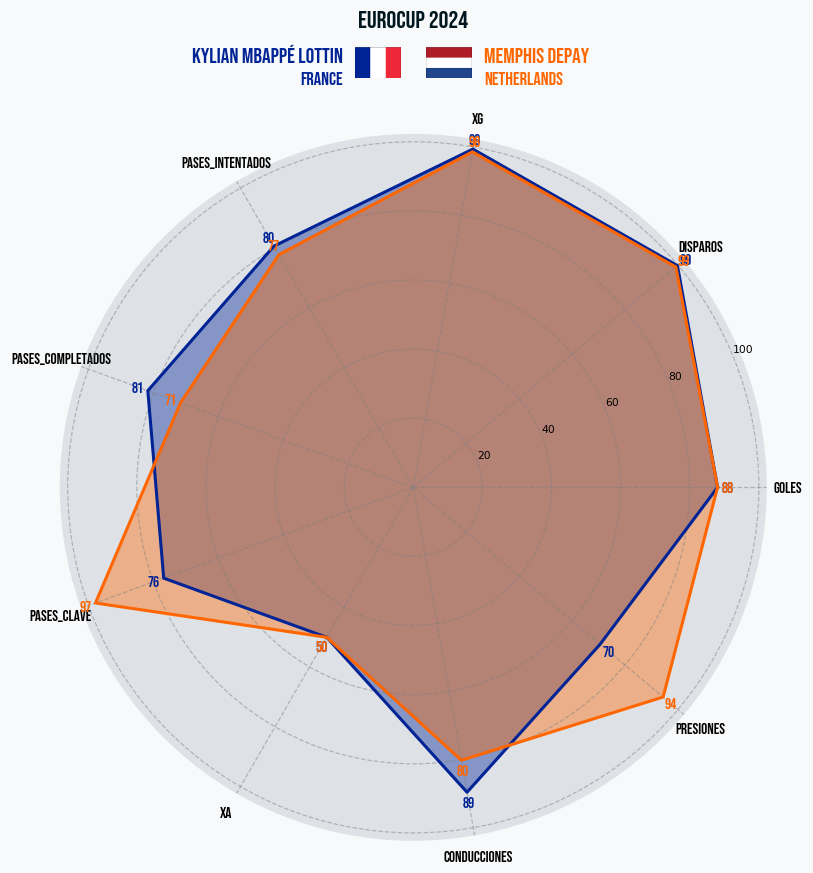

In [ ]:
# Etiquetas del radar (usamos los parámetros como etiquetas)
labels = params

# Número de variables
num_vars = len(labels)

# Ángulos del radar
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Cerrar los polígonos
player1_values += [player1_values[0]]
player2_values += [player2_values[0]]

# Crear figura
fig, ax = plt.subplots(figsize=(8, 8), dpi=110, subplot_kw=dict(polar=True))

# Texto personalizado (jugadores y equipos)
ax.text(0.5, 1.15, title, transform=ax.transAxes, ha='center', fontsize=16, color=title_color,fontproperties=font_title.prop)
ax.text(0.4, 1.1, f"{player1}", transform=ax.transAxes, ha='right', fontsize=14, color=player1_color,fontproperties=font_title.prop)
ax.text(0.6, 1.1, f"{player2}", transform=ax.transAxes, ha='left', fontsize=14, color=player2_color,fontproperties=font_title.prop)
ax.text(0.4, 1.07, f"{Team1}", transform=ax.transAxes, ha='right', fontsize=12, color=player1_color,fontproperties=font_title.prop)
ax.text(0.6, 1.07, f"{Team2}", transform=ax.transAxes, ha='left', fontsize=12, color=player2_color,fontproperties=font_title.prop)

add_image_from_url(logo_team1, x_pos=0.45, y_pos=1.1, size=0.2, relative_to='axes')
add_image_from_url(logo_team2, x_pos=0.55, y_pos=1.1, size=0.2, relative_to='axes')

# Dibujar las líneas
ax.plot(angles, player1_values, color=player1_color, linewidth=2)
ax.fill(angles, player1_values, color=player1_color, alpha=0.4)

ax.plot(angles, player2_values, color=player2_color, linewidth=2)
ax.fill(angles, player2_values, color=player2_color, alpha=0.4)


# Añadir los valores numéricos al radar
for i in range(num_vars):
    angle = angles[i]
    # Jugador 1
    ax.text(angle, player1_values[i] + 3, f"{int(player1_values[i])}", color=player1_color, fontsize=10, ha='center', va='center',fontproperties=font_title.prop)
    # Jugador 2
    ax.text(angle, player2_values[i] + 3, f"{int(player2_values[i])}", color=player2_color, fontsize=10, ha='center', va='center',fontproperties=font_title.prop)

# Añadir etiquetas
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=14, fontproperties=font_title.prop)

# Estilo del radar
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(["20", "40", "60", "80", "100"], fontsize=7)
ax.yaxis.grid(True, linestyle='dashed', color='gray', alpha=0.5)
ax.xaxis.grid(True, linestyle='dashed', color='gray', alpha=0.5)

# Ajustes finales
ax.spines['polar'].set_visible(False)

# Fondo gris del área polar
ax.set_facecolor(radar_bg_color)
fig.set_facecolor(fig_bg_color)

plt.tight_layout()